# Caution

This simulation notebook is useful as a historical scaffold, but its older outputs may combine the old triple-barrier construction, gross-only secondary exposure normalisation, and the noisy portfolio-volatility-calibrated DGP. Re-check the labeler and exposure construction before using any result for current conclusions.


# Fast Simulation Workflow

Repeated simulation version of `fast_worflow.ipynb`. The data-generating specification is kept visible, while each simulation samples a new return matrix and runs the fast primary, labeling, secondary-model, and evaluation workflow.

In [294]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

sys.path.append(str(Path().resolve().parent))

from src.primary_strategy import build_primary_momentum_strategy_fast
from src.triple_barrier_fast import simple_triple_barrier_labels_fast
from src.secondary_model_fast import (
    build_secondary_dataset_fast,
    purged_time_split,
    fit_logistic,
    apply_probability_threshold,
    threshold_diagnostics,
    create_filtered_weights_fast,
    calculate_strategy_pnl,
)
from src.evaluation_metrics import evaluate_strategy

## Data-Generation Specification

This cell defines the covariance structure and fixed universe. Change volatility, factor split, number of stocks, or number of factors here.

In [295]:
component_seed = 0
rng_components = np.random.default_rng(component_seed)

N = 500
T = 10_000
K = 10

dates = pd.date_range("1986-01-01", periods=T, freq="B")
cols = [f"Stock_{i:03d}" for i in range(N)]

target_daily_vol = 0.10 / np.sqrt(252)
split = [0.6, 0.4]
trend_daily = 0.50 / 252

wi = np.ones((N, 1)) / N

Z = rng_components.normal(0, 1, size=(N, K - 1))
Z = (Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, keepdims=True)
Z = np.concatenate([rng_components.uniform(0.5, 1.5, size=(N, 1)), Z], axis=1)

G = np.diag(np.concatenate([np.ones(1), [0.25 * np.exp(-i) for i in range(K - 1)]]))
S = rng_components.uniform(0.01, 0.25, size=N)

multf = np.squeeze(split[0] * target_daily_vol**2 / (wi.T @ (Z @ G @ Z.T) @ wi))
mults = np.squeeze(split[1] * target_daily_vol**2 / (wi.T @ np.diag(S) @ wi))

G = multf * G
cov_factor = Z @ G @ Z.T
S = mults * S
cov_specific = np.diag(S)
cov = cov_factor + cov_specific

beta = (np.eye(N) @ cov @ wi) / (wi.T @ cov @ wi)

## Simulation Inputs

Change these values to test different up/down-stock compositions, model horizons, thresholds, or simulation counts.

In [296]:
n_sims = 20  # set to 1000 for the full simulation run
base_seed = 10_000

n_up = 50
n_down = 100

lookback = 260
horizon = 30
barrier_vol_window = 20
secondary_window = 150
threshold = 0.50

train_frac = 0.50
val_frac = 0.25

feature_cols = [
    "weight",
    f"ret_{secondary_window}",
    f"vol_{secondary_window}",
]

## Minimal Helpers

Small notebook-only helpers for repeated sampling, extracting metrics, and storing simulation outputs.

In [297]:
def sample_returns(seed):
    rng = np.random.default_rng(seed)

    up_stocks = rng.choice(N, size=n_up, replace=False)
    remaining = np.setdiff1d(np.arange(N), up_stocks)
    down_stocks = rng.choice(remaining, size=n_down, replace=False)

    trend = np.zeros(N)
    trend[up_stocks] = rng.uniform(0.1, 1.0, size=n_up) * trend_daily
    trend[down_stocks] = -rng.uniform(0.1, 1.0, size=n_down) * trend_daily

    sampled_returns = rng.multivariate_normal(trend, cov, size=T)
    return pd.DataFrame(sampled_returns, index=dates, columns=cols)


def metric_value(summary, metric):
    value = summary.loc[summary["Metric"] == metric, "Value"]
    return np.nan if value.empty else float(value.iloc[0])


def safe_roc_auc(df):
    if df["label"].nunique() < 2:
        return np.nan
    return roc_auc_score(df["label"], df["probability"])


def positive_filter_stats(filtered_df):
    y_true = filtered_df["label"]
    y_pred = filtered_df["meta_label"]

    positive_total = int((y_true == 1).sum())
    positive_kept = int(((y_true == 1) & (y_pred == 1)).sum())
    positive_filtered = int(((y_true == 1) & (y_pred == 0)).sum())

    if positive_total > 0:
        positive_kept_rate = positive_kept / positive_total
        positive_filtered_rate = positive_filtered / positive_total
    else:
        positive_kept_rate = np.nan
        positive_filtered_rate = np.nan

    return {
        "positive_total": positive_total,
        "positive_kept": positive_kept,
        "positive_filtered": positive_filtered,
        "positive_kept_rate": positive_kept_rate,
        "positive_filtered_rate": positive_filtered_rate,
    }


def selected_strategy_metrics(summary, prefix):
    return {
        f"{prefix}_ann_return": metric_value(summary, "Annualized return"),
        f"{prefix}_avg_daily_return": metric_value(summary, "Average daily return"),
        f"{prefix}_sharpe": metric_value(summary, "Sharpe ratio"),
        f"{prefix}_max_drawdown": metric_value(summary, "Maximum drawdown"),
        f"{prefix}_ann_turnover": metric_value(summary, "Annualized turnover"),
    }


def standardize_gross_exposure(filtered_weights, primary_weights):
    primary_exposure = primary_weights.abs().sum(axis=1)
    filtered_exposure = filtered_weights.abs().sum(axis=1)
    scale = primary_exposure / filtered_exposure
    scale = scale.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return filtered_weights.mul(scale, axis=0)

## Run Simulations

This cell runs the full fast workflow repeatedly. Libraries and functions are imported outside the loop; only the return sampling and model workflow happen inside each simulation.

In [298]:
secondary_rows = []
strategy_rows = []

for sim in range(n_sims):
    df_returns = sample_returns(base_seed + sim)

    primary_pnl, wt, signal = build_primary_momentum_strategy_fast(
        df_returns=df_returns,
        lookback=lookback,
    )

    labels = simple_triple_barrier_labels_fast(
        df_returns=df_returns,
        wt=wt,
        horizon=horizon,
        vol_window=barrier_vol_window,
    )

    secondary_data = build_secondary_dataset_fast(
        df_returns=df_returns,
        labels=labels,
        window=secondary_window,
    )

    train_df, val_df, test_df, val_start, test_start = purged_time_split(
        df=secondary_data,
        horizon=horizon,
        train_frac=train_frac,
        val_frac=val_frac,
    )

    model, train_pred_df, val_pred_df, test_pred_df = fit_logistic(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
    )

    val_filtered_df = apply_probability_threshold(val_pred_df, threshold)
    test_filtered_df = apply_probability_threshold(test_pred_df, threshold)

    test_threshold_summary = threshold_diagnostics(test_filtered_df)
    positive_stats = positive_filter_stats(test_filtered_df)

    test_dates = pd.Index(test_filtered_df["t0"].unique())
    test_dates = test_dates.intersection(wt.index).intersection(df_returns.index).sort_values()
    test_filtered_df = test_filtered_df[test_filtered_df["t0"].isin(test_dates)].copy()

    primary_test_wt = wt.reindex(test_dates)
    primary_test_pnl = calculate_strategy_pnl(primary_test_wt, df_returns)
    primary_summary = evaluate_strategy(primary_test_pnl, primary_test_wt)

    secondary_test_wt_raw = create_filtered_weights_fast(
        primary_weights=primary_test_wt,
        filtered_df=test_filtered_df,
    )
    secondary_test_wt = standardize_gross_exposure(
        filtered_weights=secondary_test_wt_raw,
        primary_weights=primary_test_wt,
    )
    secondary_test_pnl = calculate_strategy_pnl(secondary_test_wt, df_returns)
    secondary_summary = evaluate_strategy(secondary_test_pnl, secondary_test_wt)

    secondary_rows.append({
        "sim": sim,
        "roc_auc": safe_roc_auc(test_pred_df),
        "base_positive_rate": metric_value(test_threshold_summary, "Base positive rate"),
        "positive_rate_among_kept": metric_value(test_threshold_summary, "Positive rate among kept trades"),
        "fraction_kept": metric_value(test_threshold_summary, "Fraction kept"),
        **positive_stats,
    })

    strategy_rows.append({
        "sim": sim,
        **selected_strategy_metrics(primary_summary, "primary"),
        **selected_strategy_metrics(secondary_summary, "secondary"),
    })

    if (sim + 1) % max(1, n_sims // 10) == 0:
        print(f"completed {sim + 1}/{n_sims}")

secondary_results = pd.DataFrame(secondary_rows)
strategy_results = pd.DataFrame(strategy_rows)

completed 2/20
completed 4/20
completed 6/20
completed 8/20
completed 10/20
completed 12/20
completed 14/20
completed 16/20
completed 18/20
completed 20/20


## Secondary-Model Diagnostics

In [299]:
secondary_results.head()

,sim,roc_auc,base_positive_rate,positive_rate_among_kept,fraction_kept,positive_total,positive_kept,positive_filtered,positive_kept_rate,positive_filtered_rate
0,0,0.558367,0.255909,0.288583,0.472016,310674,165366,145308,0.532281,0.467719
1,1,0.553815,0.256497,0.286874,0.473907,311387,165045,146342,0.530032,0.469968
2,2,0.554370,0.255002,0.286280,0.472576,309573,164241,145332,0.530540,0.469460
3,3,0.558199,0.259016,0.293251,0.474558,314445,168946,145499,0.537283,0.462717
4,4,0.550488,0.254783,0.283880,0.472149,309307,162717,146590,0.526070,0.473930


In [300]:
secondary_summary = secondary_results.drop(columns="sim").agg(["mean", "std", "min", "median", "max"]).T
secondary_summary

,mean,std,min,median,max
roc_auc,0.553217,0.003128,0.545349,0.552984,0.558367
base_positive_rate,0.256199,0.001877,0.252823,0.256414,0.259016
positive_rate_among_kept,0.286781,0.002477,0.281877,0.286548,0.293251
fraction_kept,0.473714,0.003416,0.468169,0.473432,0.482638
positive_total,311025.450000,2278.253705,306927.000000,311286.500000,314445.000000
positive_kept,164923.050000,1748.192795,161564.000000,164762.000000,168946.000000
positive_filtered,146102.400000,2340.429254,140358.000000,146466.000000,149622.000000
positive_kept_rate,0.530269,0.005630,0.519188,0.529658,0.544246
positive_filtered_rate,0.469731,0.005630,0.455754,0.470342,0.480812


## Primary vs Exposure-Standardised Secondary Strategy Diagnostics

In [301]:
strategy_results.head()

,sim,primary_ann_return,primary_avg_daily_return,primary_sharpe,primary_max_drawdown,primary_ann_turnover,secondary_ann_return,secondary_avg_daily_return,secondary_sharpe,secondary_max_drawdown,secondary_ann_turnover
0,0,0.001181,1.690930e-05,0.054278,-0.306170,10.994122,0.010774,0.000074,0.147944,-0.376404,13.979464
1,1,-0.015744,-5.106710e-05,-0.166143,-0.327427,11.009608,-0.022774,-0.000063,-0.131160,-0.433954,14.220538
2,2,0.002856,2.380813e-05,0.075600,-0.203064,11.045959,0.003603,0.000047,0.091991,-0.282733,13.877890
3,3,-0.003253,-3.416902e-07,-0.001081,-0.228950,10.958683,0.020075,0.000109,0.222191,-0.258398,14.012397
4,4,-0.004650,-6.432057e-06,-0.020784,-0.303209,11.073132,-0.031330,-0.000096,-0.194537,-0.526483,13.822024


In [302]:
strategy_summary = strategy_results.drop(columns="sim").agg(["mean", "std", "min", "median", "max"]).T
strategy_summary

,mean,std,min,median,max
primary_ann_return,0.011190,0.027113,-0.048311,0.014245,0.064771
primary_avg_daily_return,0.000055,0.000107,-0.000184,0.000069,0.000261
primary_sharpe,0.176249,0.344047,-0.584050,0.216199,0.854469
primary_max_drawdown,-0.224236,0.078065,-0.400663,-0.217113,-0.125218
primary_ann_turnover,10.992031,0.091858,10.839736,10.959723,11.216485
secondary_ann_return,-0.009964,0.036819,-0.118570,-0.001726,0.038782
secondary_avg_daily_return,-0.000011,0.000152,-0.000471,0.000025,0.000181
secondary_sharpe,-0.024235,0.308621,-0.971353,0.049519,0.368946
secondary_max_drawdown,-0.394292,0.116235,-0.710758,-0.389264,-0.231187
secondary_ann_turnover,14.032926,0.214151,13.764060,13.971727,14.419597


In [303]:
comparison_summary = pd.DataFrame({
    "Metric": ["Annualized return", "Average daily return", "Sharpe ratio", "Maximum drawdown", "Annualized turnover"],
    "Primary mean": [
        strategy_results["primary_ann_return"].mean(),
        strategy_results["primary_avg_daily_return"].mean(),
        strategy_results["primary_sharpe"].mean(),
        strategy_results["primary_max_drawdown"].mean(),
        strategy_results["primary_ann_turnover"].mean(),
    ],
    "Secondary mean": [
        strategy_results["secondary_ann_return"].mean(),
        strategy_results["secondary_avg_daily_return"].mean(),
        strategy_results["secondary_sharpe"].mean(),
        strategy_results["secondary_max_drawdown"].mean(),
        strategy_results["secondary_ann_turnover"].mean(),
    ],
})

comparison_summary["Secondary - Primary"] = comparison_summary["Secondary mean"] - comparison_summary["Primary mean"]
comparison_summary

,Metric,Primary mean,Secondary mean,Secondary - Primary
0,Annualized return,0.011190,-0.009964,-0.021154
1,Average daily return,0.000055,-0.000011,-0.000066
2,Sharpe ratio,0.176249,-0.024235,-0.200484
3,Maximum drawdown,-0.224236,-0.394292,-0.170056
4,Annualized turnover,10.992031,14.032926,3.040894


## Secondary-Model Boxplots

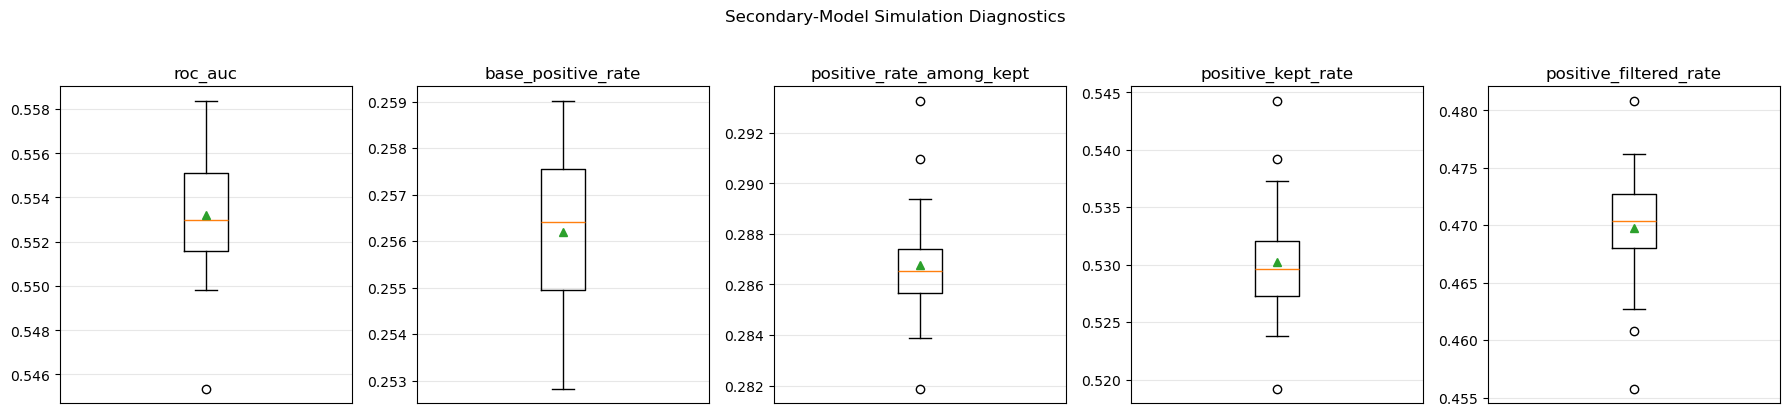

In [304]:
secondary_plot_cols = [
    "roc_auc",
    "base_positive_rate",
    "positive_rate_among_kept",
    "positive_kept_rate",
    "positive_filtered_rate",
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, secondary_plot_cols):
    ax.boxplot(secondary_results[col].dropna(), showmeans=True)
    ax.set_title(col)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Secondary-Model Simulation Diagnostics", y=1.03)
fig.tight_layout()
plt.show()

## Primary vs Exposure-Standardised Secondary Strategy Boxplots

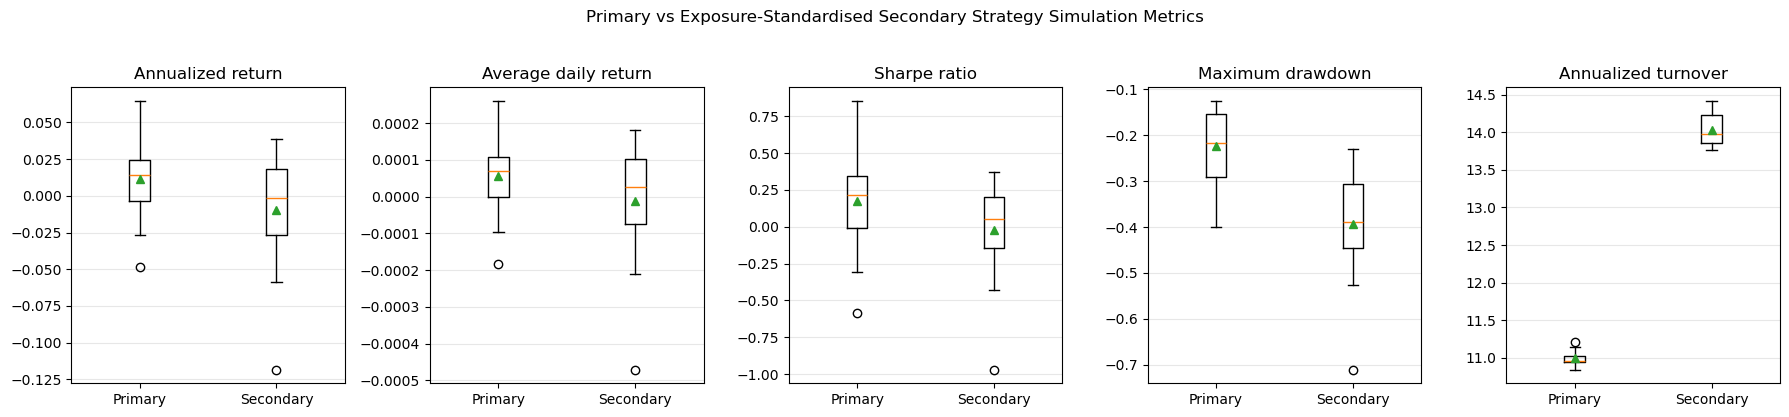

In [305]:
strategy_plot_specs = [
    ("Annualized return", "primary_ann_return", "secondary_ann_return"),
    ("Average daily return", "primary_avg_daily_return", "secondary_avg_daily_return"),
    ("Sharpe ratio", "primary_sharpe", "secondary_sharpe"),
    ("Maximum drawdown", "primary_max_drawdown", "secondary_max_drawdown"),
    ("Annualized turnover", "primary_ann_turnover", "secondary_ann_turnover"),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (title, primary_col, secondary_col) in zip(axes, strategy_plot_specs):
    ax.boxplot(
        [strategy_results[primary_col].dropna(), strategy_results[secondary_col].dropna()],
        labels=["Primary", "Secondary"],
        showmeans=True,
    )
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Primary vs Exposure-Standardised Secondary Strategy Simulation Metrics", y=1.03)
fig.tight_layout()
plt.show()

## Heatmap Simulation Grid

This section varies annual volatility and an explicit, non-symmetric up/down-stock scenario grid. The default scenarios keep `n_down=100` and vary `n_up` from 50 to 400. The secondary strategy is gross-exposure standardised before evaluation.

In [306]:
heatmap_n_sims = 20

annual_vol_grid = np.round(np.arange(0.02, 0.20 + 0.001, 0.02), 2)
trend_scenarios = pd.DataFrame({
    "scenario_order": np.arange(8),
    "n_up": np.arange(50, 401, 50),
    "n_down": 100,
})
trend_scenarios["scenario"] = (
    trend_scenarios["n_up"].astype(str)
    + "u/"
    + trend_scenarios["n_down"].astype(str)
    + "d"
)

heatmap_base_seed = 100_000
heatmap_component_seed = component_seed

annual_vol_grid, trend_scenarios

(array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ]),
    scenario_order  n_up  n_down   scenario
 0               0    50     100   50u/100d
 1               1   100     100  100u/100d
 2               2   150     100  150u/100d
 3               3   200     100  200u/100d
 4               4   250     100  250u/100d
 5               5   300     100  300u/100d
 6               6   350     100  350u/100d
 7               7   400     100  400u/100d)

In [307]:
def build_covariance_for_annual_vol(annual_vol, seed=0):
    rng = np.random.default_rng(seed)
    daily_vol = annual_vol / np.sqrt(252)

    wi_local = np.ones((N, 1)) / N

    z = rng.normal(0, 1, size=(N, K - 1))
    z = (z - z.mean(axis=1, keepdims=True)) / z.std(axis=1, keepdims=True)
    z = np.concatenate([rng.uniform(0.5, 1.5, size=(N, 1)), z], axis=1)

    g = np.diag(np.concatenate([np.ones(1), [0.25 * np.exp(-i) for i in range(K - 1)]]))
    s = rng.uniform(0.01, 0.25, size=N)

    multf = np.squeeze(split[0] * daily_vol**2 / (wi_local.T @ (z @ g @ z.T) @ wi_local))
    mults = np.squeeze(split[1] * daily_vol**2 / (wi_local.T @ np.diag(s) @ wi_local))

    g = multf * g
    s = mults * s

    return z @ g @ z.T + np.diag(s)


def sample_heatmap_returns(seed, cov_matrix, n_up_cell, n_down_cell):
    rng = np.random.default_rng(seed)

    up_stocks = rng.choice(N, size=n_up_cell, replace=False)
    remaining = np.setdiff1d(np.arange(N), up_stocks)
    down_stocks = rng.choice(remaining, size=n_down_cell, replace=False)

    trend = np.zeros(N)
    trend[up_stocks] = rng.uniform(0.1, 1.0, size=n_up_cell) * trend_daily
    trend[down_stocks] = -rng.uniform(0.1, 1.0, size=n_down_cell) * trend_daily

    sampled_returns = rng.multivariate_normal(trend, cov_matrix, size=T)
    return pd.DataFrame(sampled_returns, index=dates, columns=cols)


def run_one_heatmap_sim(seed, cov_matrix, n_up_cell, n_down_cell):
    df_returns = sample_heatmap_returns(seed, cov_matrix, n_up_cell, n_down_cell)

    primary_pnl, wt, signal = build_primary_momentum_strategy_fast(
        df_returns=df_returns,
        lookback=lookback,
    )

    labels = simple_triple_barrier_labels_fast(
        df_returns=df_returns,
        wt=wt,
        horizon=horizon,
        vol_window=barrier_vol_window,
    )

    secondary_data = build_secondary_dataset_fast(
        df_returns=df_returns,
        labels=labels,
        window=secondary_window,
    )

    train_df, val_df, test_df, val_start, test_start = purged_time_split(
        df=secondary_data,
        horizon=horizon,
        train_frac=train_frac,
        val_frac=val_frac,
    )

    model, train_pred_df, val_pred_df, test_pred_df = fit_logistic(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
    )

    test_filtered_df = apply_probability_threshold(test_pred_df, threshold)
    test_threshold_summary = threshold_diagnostics(test_filtered_df)
    positive_stats = positive_filter_stats(test_filtered_df)

    test_dates = pd.Index(test_filtered_df["t0"].unique())
    test_dates = test_dates.intersection(wt.index).intersection(df_returns.index).sort_values()
    test_filtered_df = test_filtered_df[test_filtered_df["t0"].isin(test_dates)].copy()

    primary_test_wt = wt.reindex(test_dates)
    primary_test_pnl = calculate_strategy_pnl(primary_test_wt, df_returns)
    primary_summary = evaluate_strategy(primary_test_pnl, primary_test_wt)

    secondary_test_wt_raw = create_filtered_weights_fast(
        primary_weights=primary_test_wt,
        filtered_df=test_filtered_df,
    )
    secondary_test_wt = standardize_gross_exposure(
        filtered_weights=secondary_test_wt_raw,
        primary_weights=primary_test_wt,
    )
    secondary_test_pnl = calculate_strategy_pnl(secondary_test_wt, df_returns)
    secondary_summary = evaluate_strategy(secondary_test_pnl, secondary_test_wt)

    row = {
        "roc_auc": safe_roc_auc(test_pred_df),
        "base_positive_rate": metric_value(test_threshold_summary, "Base positive rate"),
        "positive_rate_among_kept": metric_value(test_threshold_summary, "Positive rate among kept trades"),
        "fraction_kept": metric_value(test_threshold_summary, "Fraction kept"),
        **positive_stats,
        **selected_strategy_metrics(primary_summary, "primary"),
        **selected_strategy_metrics(secondary_summary, "secondary"),
    }

    row["delta_ann_return"] = row["secondary_ann_return"] - row["primary_ann_return"]
    row["delta_avg_daily_return"] = row["secondary_avg_daily_return"] - row["primary_avg_daily_return"]
    row["delta_sharpe"] = row["secondary_sharpe"] - row["primary_sharpe"]
    row["delta_max_drawdown"] = row["secondary_max_drawdown"] - row["primary_max_drawdown"]
    row["delta_ann_turnover"] = row["secondary_ann_turnover"] - row["primary_ann_turnover"]

    return row

In [308]:
heatmap_rows = []
total_runs = len(annual_vol_grid) * len(trend_scenarios) * heatmap_n_sims
completed_runs = 0

for vol_id, annual_vol in enumerate(annual_vol_grid):
    cov_heatmap = build_covariance_for_annual_vol(
        annual_vol=annual_vol,
        seed=heatmap_component_seed,
    )

    for _, scenario_row in trend_scenarios.iterrows():
        scenario_order = int(scenario_row["scenario_order"])
        scenario_label = scenario_row["scenario"]
        n_up_cell = int(scenario_row["n_up"])
        n_down_cell = int(scenario_row["n_down"])

        for sim in range(heatmap_n_sims):
            seed = heatmap_base_seed + vol_id * 100_000 + scenario_order * 100 + sim

            try:
                row = run_one_heatmap_sim(
                    seed=seed,
                    cov_matrix=cov_heatmap,
                    n_up_cell=n_up_cell,
                    n_down_cell=n_down_cell,
                )
                row["error"] = None
            except Exception as exc:
                row = {"error": str(exc)}

            row.update({
                "annual_vol": annual_vol,
                "scenario_order": scenario_order,
                "scenario": scenario_label,
                "n_up": n_up_cell,
                "n_down": n_down_cell,
                "sim": sim,
                "seed": seed,
            })
            heatmap_rows.append(row)

            completed_runs += 1
            if completed_runs % max(1, total_runs // 20) == 0:
                print(f"completed {completed_runs}/{total_runs}")

heatmap_results = pd.DataFrame(heatmap_rows)
heatmap_results.head()

completed 80/1600
completed 160/1600
completed 240/1600
completed 320/1600
completed 400/1600
completed 480/1600
completed 560/1600
completed 640/1600
completed 720/1600
completed 800/1600
completed 880/1600
completed 960/1600
completed 1040/1600
completed 1120/1600


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


completed 1200/1600


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = fu

completed 1280/1600


...

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = fu

completed 1520/1600


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = fu

completed 1600/1600


,roc_auc,base_positive_rate,positive_rate_among_kept,fraction_kept,positive_total,positive_kept,positive_filtered,positive_kept_rate,positive_filtered_rate,primary_ann_return,...,delta_max_drawdown,delta_ann_turnover,error,annual_vol,scenario_order,scenario,n_up,n_down,sim,seed
0,0.531677,0.313698,0.331709,0.448073,380829,180437,200392,0.473801,0.526199,0.135239,...,-0.001308,3.262227,None,0.02,0,50u/100d,50,100,0,100000
1,0.528761,0.306484,0.326400,0.460538,372071,182488,189583,0.490466,0.509534,0.115102,...,-0.000334,2.246880,None,0.02,0,50u/100d,50,100,1,100001
2,0.536728,0.307582,0.330958,0.446933,373404,179570,193834,0.480900,0.519100,0.119699,...,0.002387,1.664648,None,0.02,0,50u/100d,50,100,2,100002
3,0.534410,0.313647,0.335920,0.428225,380767,174633,206134,0.458635,0.541365,0.133837,...,0.000801,7.119254,None,0.02,0,50u/100d,50,100,3,100003
4,0.525250,0.310577,0.325398,0.440778,377041,174122,202919,0.461812,0.538188,0.127351,...,-0.002246,4.018370,None,0.02,0,50u/100d,50,100,4,100004


In [309]:
heatmap_summary = (
    heatmap_results
    .groupby(["annual_vol", "scenario_order", "scenario", "n_up", "n_down"], as_index=False)
    .mean(numeric_only=True)
)

heatmap_summary.head()

,annual_vol,scenario_order,scenario,n_up,n_down,roc_auc,base_positive_rate,positive_rate_among_kept,fraction_kept,positive_total,...,secondary_sharpe,secondary_max_drawdown,secondary_ann_turnover,delta_ann_return,delta_avg_daily_return,delta_sharpe,delta_max_drawdown,delta_ann_turnover,sim,seed
0,0.02,0,50u/100d,50,100,0.528046,0.309773,0.326936,0.449692,376065.00,...,7.807348,-0.007522,13.608834,0.035571,0.000124,0.027681,-0.001191,4.499668,9.5,100009.5
1,0.02,1,100u/100d,100,100,0.538841,0.321793,0.347280,0.458089,390656.85,...,11.008238,-0.005090,10.241472,0.038517,0.000129,0.493583,-0.000264,1.731954,9.5,100109.5
2,0.02,2,150u/100d,150,100,0.547712,0.332420,0.364504,0.462811,403557.95,...,12.296851,-0.004911,9.374656,0.044237,0.000144,-0.043570,-0.000733,1.276347,9.5,100209.5
3,0.02,3,200u/100d,200,100,0.557035,0.340323,0.378703,0.455721,413151.60,...,12.941019,-0.004899,9.047858,0.055326,0.000177,-0.700018,-0.001261,1.266886,9.5,100309.5
4,0.02,4,250u/100d,250,100,0.562343,0.346842,0.389259,0.451743,421066.00,...,13.225764,-0.005070,8.966980,0.062641,0.000197,-1.169229,-0.001600,1.381187,9.5,100409.5


## Secondary-Model Heatmaps

In [310]:
def plot_heatmap_grid(summary_df, metric_specs, title, cmap="viridis", figsize=(18, 4)):
    fig, axes = plt.subplots(1, len(metric_specs), figsize=figsize, constrained_layout=True)

    if len(metric_specs) == 1:
        axes = [axes]

    for ax, (metric, label) in zip(axes, metric_specs):
        scenario_order = (
            summary_df[["scenario", "scenario_order"]]
            .drop_duplicates()
            .sort_values("scenario_order")
        )
        matrix = summary_df.pivot(
            index="scenario",
            columns="annual_vol",
            values=metric,
        ).reindex(scenario_order["scenario"])

        im = ax.imshow(matrix.values, aspect="auto", origin="lower", cmap=cmap)
        ax.set_title(label)
        ax.set_xlabel("Annual volatility")
        ax.set_ylabel("Up/down scenario")
        ax.set_xticks(np.arange(len(matrix.columns)))
        ax.set_xticklabels([f"{x:.2f}" for x in matrix.columns], rotation=45)
        ax.set_yticks(np.arange(len(matrix.index)))
        ax.set_yticklabels(matrix.index)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title, y=1.08)
    return fig, axes

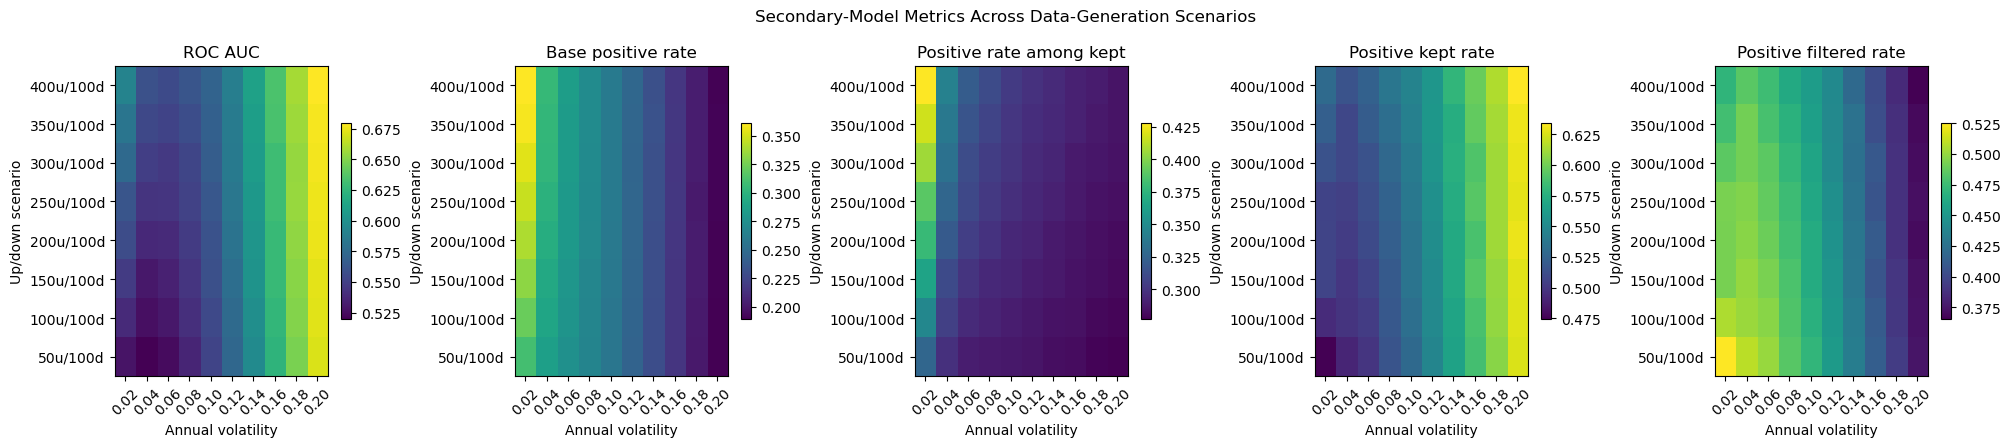

In [311]:
secondary_heatmap_metrics = [
    ("roc_auc", "ROC AUC"),
    ("base_positive_rate", "Base positive rate"),
    ("positive_rate_among_kept", "Positive rate among kept"),
    ("positive_kept_rate", "Positive kept rate"),
    ("positive_filtered_rate", "Positive filtered rate"),
]

plot_heatmap_grid(
    heatmap_summary,
    secondary_heatmap_metrics,
    title="Secondary-Model Metrics Across Data-Generation Scenarios",
    cmap="viridis",
    figsize=(20, 4),
)
plt.show()

## Primary vs Secondary Improvement Heatmaps

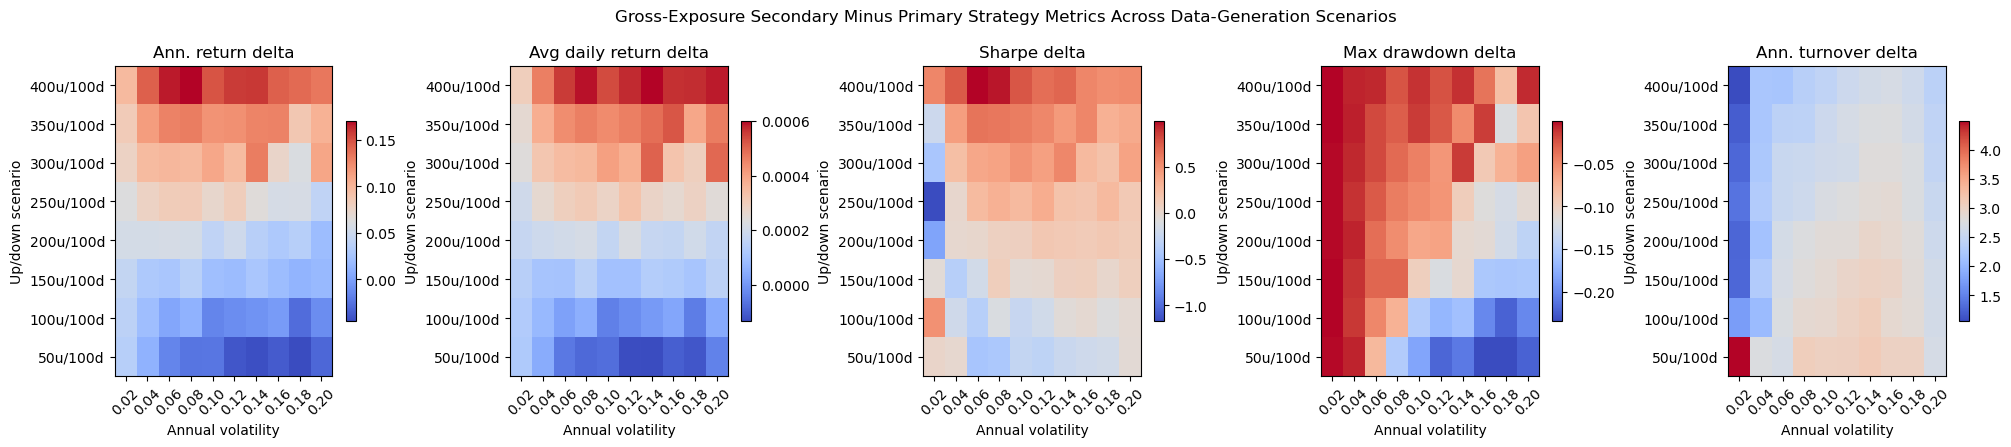

In [312]:
strategy_delta_heatmap_metrics = [
    ("delta_ann_return", "Ann. return delta"),
    ("delta_avg_daily_return", "Avg daily return delta"),
    ("delta_sharpe", "Sharpe delta"),
    ("delta_max_drawdown", "Max drawdown delta"),
    ("delta_ann_turnover", "Ann. turnover delta"),
]

plot_heatmap_grid(
    heatmap_summary,
    strategy_delta_heatmap_metrics,
    title="Gross-Exposure Secondary Minus Primary Strategy Metrics Across Data-Generation Scenarios",
    cmap="coolwarm",
    figsize=(20, 4),
)
plt.show()

In [313]:
heatmap_error_summary = (
    heatmap_results[heatmap_results["error"].notna()]
    .groupby(["annual_vol", "scenario", "error"])
    .size()
    .reset_index(name="count")
)

heatmap_error_summary

,annual_vol,scenario,error,count
